## 00. Import Required Packages and Tools

In [1]:
# Quick verification of wave_tools availability
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
import pandas as pd
from wave_tools import (save_figure)
from wave_tools.spectral import (WKSpectralAnalysis, SpectralConfig)

# 图像保存路径
fig_save_path = "/work/mh1498/m301257/figures/wave_analysis/"
os.makedirs(fig_save_path, exist_ok=True)

# 地球物理常数
EARTH_RADIUS = 6.37e6  # 地球半径 (m)

# Check key files
key_files = ['__init__.py', 'spectral.py', 'plotting.py', 'utils.py']
print(f"\n2. Key files check:")
for file in key_files:
    file_path = os.path.join(WAVE_TOOLS_PATH, file)
    exists = os.path.exists(file_path)
    symbol = "✓" if exists else "✗"
    print(f"   {symbol} {file}: {'exists' if exists else 'not found'}")




2. Key files check:
   ✓ __init__.py: exists
   ✓ spectral.py: exists
   ✓ plotting.py: exists
   ✓ utils.py: exists


## 02. Kelvin Wave Selection and Phase Speed Calculation Core Functions

Implementation based on the methodology from Cal_+4K_data_kelvin.ipynb

In [2]:
def create_kelvin_wave_mask(
    frequency: np.ndarray,
    wavenumber: np.ndarray,
    fmin: float = 1/20,
    fmax: float = 1/3,
    kmin: int = 2,
    kmax: int = 14,
    hmin: float = 8,
    hmax: float = 90
):
    
    """
    创建Kelvin波的频率-波数空间掩码
    
    参考: Wheeler & Kiladis (1999) 的Kelvin波选择标准
    频率范围: 0.03-0.3 cpd
    波数范围: 1-14
    等效深度: 8-90m (对应相速度约8-30 m/s)
    """
    EARTH_CIRCUMFERENCE = 40075e3  # 地球周长 (m)
    
    SECONDS_PER_DAY = 86400  # 每天秒数
    # 地球参数
    a = EARTH_RADIUS  # 地球半径 (m)
    g = 9.81  # 重力加速度 (m/s^2)
    beta = 2.28e-11  # 科氏参数变化率 (1/m/s)
    knum, freq = np.meshgrid(wavenumber, frequency)
    
    mask = np.zeros(knum.shape, dtype=bool)
    
    # 应用频率和波数范围
    mask = mask | (knum < kmin) | (knum > kmax)
    mask = mask | (freq < fmin) | (freq > fmax)
    
    # 应用等效深度范围（Kelvin波色散关系）
    if hmin is not None:
        c = np.sqrt(g * hmin)
        omega = 2. * np.pi * freq / 24. / 3600. / np.sqrt(beta * c)
        k = knum / a * np.sqrt(c / beta)
        mask = mask | (omega - k < 0)
    
    if hmax is not None:
        c = np.sqrt(g * hmax)
        omega = 2. * np.pi * freq / 24. / 3600. / np.sqrt(beta * c)
        k = knum / a * np.sqrt(c / beta)
        mask = mask | (omega - k > 0)
    
    valid_mask = ~mask
    
    return valid_mask.astype(float)


def calculate_kelvin_wave_metrics(analysis, freq_array, wnum_array):
    """
    计算Kelvin波的关键指标：
    1. 标准化频谱总强度
    2. 频谱加权平均相速度
    
    参数:
        analysis: WKSpectralAnalysis对象
        freq_array: 频率数组
        wnum_array: 波数数组
    
    返回:
        dict: 包含power_norm_total和speed_norm_avg的字典
    """
    a = EARTH_RADIUS  # 地球半径 (m)
    # 创建Kelvin波掩码
    valid_mask = create_kelvin_wave_mask(freq_array, wnum_array)
    
    # 获取标准化频谱
    power_sym = analysis.power_symmetric
    background = analysis.background
    
    normlized_spectrum = power_sym / background 
    norm_kelvin = normlized_spectrum * valid_mask
    
    knum, freq = np.meshgrid(wnum_array, freq_array)
    # 转换为numpy数组（如果是xarray）
    # power_sym_np = power_sym.values if hasattr(power_sym, 'values') else power_sym
    # background_np = background.values if hasattr(background, 'values') else background
    
    total_weighted_speed = 0
    total_weight = 0
    
    for i in range(knum.shape[0]):  # 频率维度
        for j in range(knum.shape[1]):  # 波数维度
            if valid_mask[i, j] and norm_kelvin[i, j] > 0:  # 有效且有功率
                f_val = freq[i, j]
                k_val = knum[i, j]
                
                # 计算相速度
                phase_speed = (2 * np.pi * f_val / 86400) / (k_val /a)
                
                # 用功率值作为权重
                weight = norm_kelvin[i, j]
                total_weighted_speed += phase_speed * weight
                total_weight += weight
    
    # 计算加权平均相速度
    if total_weight > 0:
        avg_phase_speed = total_weighted_speed / total_weight
    else:
        avg_phase_speed = np.nan
        print("警告: 没有找到有效的Kelvin波区域数据点")
    
    return {
        'speed_norm_avg': avg_phase_speed,
        'valid_mask': valid_mask,
        'norm_spectrum': norm_kelvin
    }

print("✅ Kelvin wave analysis functions defined successfully")

✅ Kelvin wave analysis functions defined successfully


In [4]:
xr.open_dataset(f"{data_base_path}/pr_cntl_2deg_interp.nc")

<xarray.Dataset> Size: 111MB
Dimensions:                        (time: 5114, lat: 15, lon: 180)
Coordinates:
  * time                           (time) datetime64[ns] 41kB 1980-01-01 ... ...
  * lat                            (lat) float64 120B -14.0 -12.0 ... 12.0 14.0
  * lon                            (lon) float64 1kB 0.0 2.0 4.0 ... 356.0 358.0
Data variables:
    __xarray_dataarray_variable__  (time, lat, lon) float64 110MB ...

## 03. Load Preprocessed Precipitation Data

Use already processed precipitation data (converted to lat-lon grid and mm/day units)

In [5]:
# 指定已处理的数据路径
print("="*70)
print("📁 加载已处理的降水数据...")
print("="*70)

# 数据路径 - 请根据实际情况修改 /work/mh1498/m301257/processed_data/pr_4co2_2deg_interp.nc
data_base_path = "/work/mh1498/m301257/processed_data/"

# 可用的实验列表 - 包含CNTL对照实验
experiments = ['CNTL', '4K', '4CO2']

# 检查是否有已加载的数据 
data_dict = {}

print("\n正在加载三个实验的数据:")
print("  - CNTL: 对照实验")
print("  - 4K: +4K SST敏感性实验")
print("  - 4CO2: 4×CO2敏感性实验")

# 加载数据
import xarray as xr
try:
    data_dict['CNTL'] = xr.open_dataset(f"{data_base_path}/pr_cntl_2deg_interp.nc")['__xarray_dataarray_variable__'].sel(lat=slice(-15,15))
    print("✓ CNTL数据加载成功")
except Exception as e:
    print(f"⚠️ CNTL数据加载失败: {e}")

try:
    data_dict['4K'] = xr.open_dataset(f"{data_base_path}/pr_p4k_2deg_interp.nc")['__xarray_dataarray_variable__'].sel(lat=slice(-15,15))
    print("✓ 4K数据加载成功")
except Exception as e:
    print(f"⚠️ 4K数据加载失败: {e}")

try:
    data_dict['4CO2'] = xr.open_dataset(f"{data_base_path}/pr_4co2_2deg_interp.nc")['__xarray_dataarray_variable__'].sel(lat=slice(-15,15))
    print("✓ 4CO2数据加载成功")
except Exception as e:
    print(f"⚠️ 4CO2数据加载失败: {e}")

print("\n" + "="*70)
print(f"✅ 成功加载 {len(data_dict)} 个实验的数据")
print("="*70)

# 显示数据信息
for exp_name, data in data_dict.items():
    if data is not None:
        print(data)
        print(f"\n{exp_name}:")
        print(f"  形状: {data.shape}")
        print(f"  时间范围: {data.time.values[0]} 到 {data.time.values[-1]}")

📁 加载已处理的降水数据...

正在加载三个实验的数据:
  - CNTL: 对照实验
  - 4K: +4K SST敏感性实验
  - 4CO2: 4×CO2敏感性实验
✓ CNTL数据加载成功
✓ 4K数据加载成功
✓ 4CO2数据加载成功

✅ 成功加载 3 个实验的数据
<xarray.DataArray '__xarray_dataarray_variable__' (time: 5114, lat: 15, lon: 180)> Size: 110MB
[13807800 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

CNTL:
  形状: (5114, 15, 180)
  时间范围: 1980-01-01T00:00:00.000000000 到 1993-12-31T00:00:00.000000000
<xarray.DataArray '__xarray_dataarray_variable__' (time: 5114, lat: 15, lon: 180)> Size: 110MB
[13807800 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

4

## 04. Main Function for Yearly Spectral Analysis

Define function to perform Wheeler-Kiladis spectral analysis for each individual year

In [6]:
def analyze_yearly_spectrum(data, year, config=None):
    """
    对单个年份的数据进行Wheeler-Kiladis频谱分析
    
    参数:
        data: xr.DataArray, 单年降水数据
        year: int, 年份
        config: SpectralConfig对象，默认为None则使用默认配置
    
    返回:
        dict: 包含频谱分析结果和Kelvin波指标
    """
    year_data = {}
    # 使用默认配置
    if config is None:
        config = SpectralConfig()
    
    print(f"  分析 {year} 年数据...")
    print(f"    数据时间范围: {data.time.values[0]} 到 {data.time.values[-1]}")
    print(f"    数据形状: {data.shape}")
    
    # 进行频谱分析
    analysis = WKSpectralAnalysis(config)
    analysis.load_data(data=data)
    analysis.preprocess()
    analysis.compute_spectrum()
    analysis.smooth_background()  # 计算背景谱
    
    # 获取频率和波数数组
    freq_array = analysis.frequency  # 已经是numpy数组
    wnum_array = analysis.wavenumber  # 已经是numpy数组
    
    # 计算Kelvin波指标
    metrics = calculate_kelvin_wave_metrics(analysis, freq_array, wnum_array)
    
    
    print(f"    ✓ 平均相速度: {metrics['speed_norm_avg']:.2f} m/s")
    
    year_data[str(year)] = {    
        'analysis': analysis,
        'metrics': metrics,
        'freq_array': freq_array,
        'wnum_array': wnum_array,
        'time':np.unique(data['time.year'].values)
    }
    return year_data



In [7]:
def extract_wk_results():
    yearly_results = {}
    for exp_name, data in data_dict.items():
        if data is None:
            continue
        
        print("\n" + "="*70)
        print(f"📊 开始分析实验: {exp_name}")
        print("="*70)
        
        experiment = {}
        
        # 获取年份列表
        years = np.unique(data['time.year'].values)
        
        print(f"\n实验 {exp_name} 包含年份: {years}")
        for year in years:
            # 提取单年数据
            yearly_data = data.sel(time=str(year))
            print(f"\n分析年份: {year}")
            # 分析该年份数据
            print(yearly_data)
            result = analyze_yearly_spectrum(yearly_data, year)
            print(result)
        #     # 分析该年份数据
        #     result = analyze_yearly_spectrum(yearly_data, year)
            experiment.update(result)
        yearly_results[exp_name] = experiment
        print(f"\n✅ 完成实验 {exp_name} 的所有年份分析，共分析 {len(experiment)} 年份数据。")
    return yearly_results

yearly_results = extract_wk_results()


📊 开始分析实验: CNTL

实验 CNTL 包含年份: [1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993]

分析年份: 1980
<xarray.DataArray '__xarray_dataarray_variable__' (time: 366, lat: 15, lon: 180)> Size: 8MB
[988200 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-01-02 ... 1980-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  分析 1980 年数据...
    数据时间范围: 1980-01-01T00:00:00.000000000 到 1980-12-31T00:00:00.000000000
    数据形状: (366, 15, 180)
数据已加载: (366, 15, 180) (time, lat, lon)
预处理中...
预处理完成，耗时 0.3 秒
  数据形状: (366, 15, 180)
  纬度范围: [-14. -12. -10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.   8.  10.  12.
  14.]
计算功率谱...
窗口大小: 96天, 跳跃: 30天, 总窗口数: 3
功率谱计算完成，耗时 0.1 秒
平滑背景谱...
背景谱平滑完成
    ✓ 平均相速度: 15.53 m/s
{'1980': {'analysis': <wave_tools.spectral.WKSpectralAnalysis object at 0x7f2070ff09e0>, 'metrics': {'speed_norm_avg': <xarray.Data

In [8]:
yearly_results.keys()

dict_keys(['CNTL', '4K', '4CO2'])

## 06. Extract Kelvin Wave Speed Time Series from Results

Extract the weighted average Kelvin wave phase speed for each year and experiment

In [9]:
def extract_kelvin_speed_timeseries(yearly_results):
    """
    从yearly_results中提取每个实验的每年的Kelvin波加权平均相速度
    
    参数:
        yearly_results: dict, 包含所有实验和年份的分析结果
        结构: {exp_name: {year: {analysis, metrics, ...}}}
    
    返回:
        dict: {exp_name: {'years': array, 'speeds': array}}
    """
    timeseries_dict = {}
    
    for exp_name, exp_data in yearly_results.items():
        years = []
        speeds = []
        
        print(f"\n{'='*70}")
        print(f"📊 提取实验 {exp_name} 的时间序列")
        print('='*70)
        
        # 按年份排序
        sorted_years = sorted(exp_data.keys())
        
        for year in sorted_years:
            year_result = exp_data[year]
            
            # 提取加权平均相速度
            speed = year_result['metrics']['speed_norm_avg']
            
            years.append(int(year))
            speeds.append(speed)
            
            print(f"  年份 {year}: 加权平均相速度 = {speed:.3f} m/s")
        
        # 转换为numpy数组
        timeseries_dict[exp_name] = {
            'years': np.array(years),
            'speeds': np.array(speeds)
        }
        
        print(f"\n✅ {exp_name}: 成功提取 {len(years)} 年的数据")
        print(f"   年份范围: {years[0]} - {years[-1]}")
        print(f"   速度范围: {np.min(speeds):.3f} - {np.max(speeds):.3f} m/s")
        print(f"   平均速度: {np.mean(speeds):.3f} ± {np.std(speeds):.3f} m/s")
    
    return timeseries_dict

# 提取时间序列
print("="*70)
print("🔍 开始提取Kelvin波相速度时间序列...")
print("="*70)

speed_timeseries = extract_kelvin_speed_timeseries(yearly_results)

print("\n" + "="*70)
print("✅ 时间序列提取完成！")
print("="*70)
print(f"可用实验: {list(speed_timeseries.keys())}")

🔍 开始提取Kelvin波相速度时间序列...

📊 提取实验 CNTL 的时间序列
  年份 1980: 加权平均相速度 = 15.527 m/s
  年份 1981: 加权平均相速度 = 15.432 m/s
  年份 1982: 加权平均相速度 = 15.578 m/s
  年份 1983: 加权平均相速度 = 15.721 m/s
  年份 1984: 加权平均相速度 = 15.371 m/s
  年份 1985: 加权平均相速度 = 15.419 m/s
  年份 1986: 加权平均相速度 = 15.469 m/s
  年份 1987: 加权平均相速度 = 15.502 m/s
  年份 1988: 加权平均相速度 = 15.318 m/s
  年份 1989: 加权平均相速度 = 15.410 m/s
  年份 1990: 加权平均相速度 = 15.550 m/s
  年份 1991: 加权平均相速度 = 15.582 m/s
  年份 1992: 加权平均相速度 = 15.596 m/s
  年份 1993: 加权平均相速度 = 15.400 m/s

✅ CNTL: 成功提取 14 年的数据
   年份范围: 1980 - 1993
   速度范围: 15.318 - 15.721 m/s
   平均速度: 15.491 ± 0.104 m/s

📊 提取实验 4K 的时间序列
  年份 1980: 加权平均相速度 = 15.532 m/s
  年份 1981: 加权平均相速度 = 15.639 m/s
  年份 1982: 加权平均相速度 = 15.544 m/s
  年份 1983: 加权平均相速度 = 15.695 m/s
  年份 1984: 加权平均相速度 = 15.484 m/s
  年份 1985: 加权平均相速度 = 15.550 m/s
  年份 1986: 加权平均相速度 = 15.476 m/s
  年份 1987: 加权平均相速度 = 15.714 m/s
  年份 1988: 加权平均相速度 = 15.715 m/s
  年份 1989: 加权平均相速度 = 15.672 m/s
  年份 1990: 加权平均相速度 = 15.660 m/s
  年份 1991: 加权平均相速度 = 15.683 m/s
  年份 199

In [10]:
# 查看提取的数据结构
print("\n" + "="*70)
print("📋 提取结果预览:")
print("="*70)

for exp_name, data in speed_timeseries.items():
    print(f"\n{exp_name}:")
    print(f"  年份: {data['years']}")
    print(f"  速度 (m/s): {data['speeds']}")
    print(f"  数据点数: {len(data['years'])}")


📋 提取结果预览:

CNTL:
  年份: [1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993]
  速度 (m/s): [15.52686093 15.43249957 15.57762875 15.72062399 15.37062448 15.41867452
 15.4688321  15.50211394 15.31844198 15.4102334  15.54976081 15.58180228
 15.59604995 15.40034608]
  数据点数: 14

4K:
  年份: [1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993]
  速度 (m/s): [15.53173992 15.63911328 15.5442249  15.69516897 15.48444117 15.55008001
 15.47643586 15.71425634 15.71522557 15.6724985  15.66044744 15.68334628
 15.63816777 15.67214674]
  数据点数: 14

4CO2:
  年份: [1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993]
  速度 (m/s): [15.43379027 15.46350929 15.55744942 15.61663978 15.54647728 15.49217838
 15.4258402  15.47486427 15.54927858 15.59082458 15.58072734 15.48414653
 15.60254652 15.48640102]
  数据点数: 14


## 05. Trend Analysis and Significance Testing Functions

In [11]:
def perform_trend_analysis(years, values, variable_name="Variable"):
    """
    对时间序列进行线性回归和显著性检验
    
    参数:
        years: array-like, 年份数组
        values: array-like, 对应的值
        variable_name: str, 变量名称
    
    返回:
        dict: 包含回归结果和显著性检验
    """
    from scipy.stats import linregress
    # 线性回归
    slope, intercept, r_value, p_value, std_err = linregress(years, values)
    
    # 计算趋势
    trend_per_year = slope
    trend_percent = (slope / np.mean(values)) * 100  # 相对于均值的百分比变化
    
    # 判断显著性
    if p_value < 0.001:
        significance = "***"
        sig_text = "极显著"
    elif p_value < 0.01:
        significance = "**"
        sig_text = "非常显著"
    elif p_value < 0.05:
        significance = "*"
        sig_text = "显著"
    else:
        significance = "n.s."
        sig_text = "不显著"
    
    # 判断趋势方向
    if abs(slope) < 0.001:
        trend_direction = "无明显趋势"
    elif slope > 0:
        trend_direction = "增强" if sig_text != "不显著" else "微弱增强（不显著）"
    else:
        trend_direction = "减弱" if sig_text != "不显著" else "微弱减弱（不显著）"
    
    results = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err,
        'significance': significance,
        'sig_text': sig_text,
        'trend_per_year': trend_per_year,
        'trend_percent': trend_percent,
        'trend_direction': trend_direction,
        'mean_value': np.mean(values),
        'std_value': np.std(values)
    }
    
    return results



## 08. Calculate Speed Anomalies Relative to CNTL

Calculate the difference between 4K/4CO2 and CNTL experiments for each year

In [12]:
def calculate_speed_anomalies(speed_timeseries):
    """
    计算4K和4CO2实验相对于CNTL的速度差异（异常值）
    
    参数:
        speed_timeseries: dict, 包含所有实验的时间序列
        
    返回:
        dict: 包含异常值时间序列的字典
    """
    # 提取CNTL数据
    cntl_years = speed_timeseries['CNTL']['years']
    cntl_speeds = speed_timeseries['CNTL']['speeds']
    
    anomalies = {}
    
    print("="*70)
    print("📊 计算相对于CNTL的速度异常值")
    print("="*70)
    
    for exp_name in ['4K', '4CO2']:
        exp_years = speed_timeseries[exp_name]['years']
        exp_speeds = speed_timeseries[exp_name]['speeds']
        
        # 找到共同的年份
        common_years = np.intersect1d(cntl_years, exp_years)
        
        if len(common_years) == 0:
            print(f"\n⚠️ {exp_name} 和 CNTL 没有共同年份！")
            continue
        
        # 提取共同年份的速度
        cntl_mask = np.isin(cntl_years, common_years)
        exp_mask = np.isin(exp_years, common_years)
        
        cntl_speeds_common = cntl_speeds[cntl_mask]
        exp_speeds_common = exp_speeds[exp_mask]
        
        # 计算差异（异常值）
        speed_anomaly = exp_speeds_common - cntl_speeds_common
        
        anomalies[exp_name] = {
            'years': common_years,
            'anomaly': speed_anomaly,
            'exp_speeds': exp_speeds_common,
            'cntl_speeds': cntl_speeds_common
        }
        
        print(f"\n{exp_name}:")
        print(f"  共同年份数: {len(common_years)}")
        print(f"  年份范围: {common_years[0]} - {common_years[-1]}")
        print(f"  平均异常值: {np.mean(speed_anomaly):.4f} m/s")
        print(f"  异常值标准差: {np.std(speed_anomaly):.4f} m/s")
        print(f"  异常值范围: [{np.min(speed_anomaly):.4f}, {np.max(speed_anomaly):.4f}] m/s")
    
    return anomalies

# 计算异常值
speed_anomalies = calculate_speed_anomalies(speed_timeseries)

print("\n" + "="*70)
print("✅ 速度异常值计算完成！")
print("="*70)

📊 计算相对于CNTL的速度异常值

4K:
  共同年份数: 14
  年份范围: 1980 - 1993
  平均异常值: 0.1288 m/s
  异常值标准差: 0.1231 m/s
  异常值范围: [-0.0334, 0.3968] m/s

4CO2:
  共同年份数: 14
  年份范围: 1980 - 1993
  平均异常值: 0.0307 m/s
  异常值标准差: 0.1036 m/s
  异常值范围: [-0.1040, 0.2308] m/s

✅ 速度异常值计算完成！


In [16]:
def calculate_speed_3(speed_timeseries):
    """
    计算4K和4CO2实验相对于CNTL的速度差异（异常值）
    
    参数:
        speed_timeseries: dict, 包含所有实验的时间序列
        
    返回:
        dict: 包含异常值时间序列的字典
    """
    # 提取CNTL数据
    cntl_years = speed_timeseries['CNTL']['years']
    cntl_speeds = speed_timeseries['CNTL']['speeds']
    
    anomalies = {}
    
    print("="*70)
    print("📊 计算相对于CNTL的速度异常值")
    print("="*70)
    
    for exp_name in ['CNTL', '4K', '4CO2']:
        exp_years = speed_timeseries[exp_name]['years']
        exp_speeds = speed_timeseries[exp_name]['speeds']
        
        # 找到共同的年份
        common_years = np.intersect1d(cntl_years, exp_years)
        
        if len(common_years) == 0:
            print(f"\n⚠️ {exp_name} 和 CNTL 没有共同年份！")
            continue
        
        # 提取共同年份的速度
        cntl_mask = np.isin(cntl_years, common_years)
        exp_mask = np.isin(exp_years, common_years)
        
        cntl_speeds_common = cntl_speeds[cntl_mask]
        exp_speeds_common = exp_speeds[exp_mask]
        
        # 计算差异（异常值）
        speed_anomaly = exp_speeds_common - cntl_speeds_common
        
        anomalies[exp_name] = {
            'years': common_years,
            'anomaly': speed_anomaly,
            'exp_speeds': exp_speeds_common,
            'cntl_speeds': cntl_speeds_common
        }
        
        print(f"\n{exp_name}:")
        print(f"  共同年份数: {len(common_years)}")
        print(f"  年份范围: {common_years[0]} - {common_years[-1]}")
        print(f"  平均异常值: {np.mean(speed_anomaly):.4f} m/s")
        print(f"  异常值标准差: {np.std(speed_anomaly):.4f} m/s")
        print(f"  异常值范围: [{np.min(speed_anomaly):.4f}, {np.max(speed_anomaly):.4f}] m/s")
    
    return anomalies

# 计算异常值
speed_3 = calculate_speed_3(speed_timeseries)

print("\n" + "="*70)
print("✅ 速度异常值计算完成！")
print("="*70)

📊 计算相对于CNTL的速度异常值

CNTL:
  共同年份数: 14
  年份范围: 1980 - 1993
  平均异常值: 0.0000 m/s
  异常值标准差: 0.0000 m/s
  异常值范围: [0.0000, 0.0000] m/s

4K:
  共同年份数: 14
  年份范围: 1980 - 1993
  平均异常值: 0.1288 m/s
  异常值标准差: 0.1231 m/s
  异常值范围: [-0.0334, 0.3968] m/s

4CO2:
  共同年份数: 14
  年份范围: 1980 - 1993
  平均异常值: 0.0307 m/s
  异常值标准差: 0.1036 m/s
  异常值范围: [-0.1040, 0.2308] m/s

✅ 速度异常值计算完成！


In [17]:
speed_3

{'CNTL': {'years': array([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
         1991, 1992, 1993]),
  'anomaly': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
  'exp_speeds': array([15.52686093, 15.43249957, 15.57762875, 15.72062399, 15.37062448,
         15.41867452, 15.4688321 , 15.50211394, 15.31844198, 15.4102334 ,
         15.54976081, 15.58180228, 15.59604995, 15.40034608]),
  'cntl_speeds': array([15.52686093, 15.43249957, 15.57762875, 15.72062399, 15.37062448,
         15.41867452, 15.4688321 , 15.50211394, 15.31844198, 15.4102334 ,
         15.54976081, 15.58180228, 15.59604995, 15.40034608])},
 '4K': {'years': array([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
         1991, 1992, 1993]),
  'anomaly': array([ 0.00487899,  0.2066137 , -0.03340386, -0.02545501,  0.11381669,
          0.13140549,  0.00760376,  0.2121424 ,  0.39678359,  0.2622651 ,
          0.11068664,  0.101544  ,  0.04211781,  0.27180067]),
  'exp_s

In [13]:
# 对异常值进行趋势分析
print("="*70)
print("📈 对速度异常值进行趋势分析")
print("="*70)

anomaly_trends = {}

for exp_name, data in speed_anomalies.items():
    print(f"\n{'='*70}")
    print(f"实验: {exp_name} - CNTL")
    print('='*70)
    
    years = data['years']
    anomaly = data['anomaly']
    
    # 进行趋势分析
    trend = perform_trend_analysis(years, anomaly, f"{exp_name} - CNTL 速度异常值")
    
    anomaly_trends[exp_name] = trend
    
    # 打印结果
    print(f"\n  平均异常值: {trend['mean_value']:.4f} m/s")
    print(f"  异常值标准差: {trend['std_value']:.4f} m/s")
    print(f"  趋势方向: {trend['trend_direction']}")
    print(f"  斜率: {trend['slope']:.5f} m/s/年")
    print(f"  相对变化率: {trend['trend_percent']:.3f} %/年")
    print(f"  R²: {trend['r_squared']:.4f}")
    print(f"  p值: {trend['p_value']:.4f} {trend['significance']}")
    print(f"  显著性: {trend['sig_text']}")
    
    # 判断是否显著不同于零
    if abs(trend['mean_value']) > 2 * trend['std_err']:
        print(f"  *** 平均异常值显著不同于零！")
    else:
        print(f"  平均异常值与零无显著差异")

print("\n" + "="*70)
print("✅ 异常值趋势分析完成！")
print("="*70)

📈 对速度异常值进行趋势分析

实验: 4K - CNTL

  平均异常值: 0.1288 m/s
  异常值标准差: 0.1231 m/s
  趋势方向: 微弱增强（不显著）
  斜率: 0.01224 m/s/年
  相对变化率: 9.508 %/年
  R²: 0.1608
  p值: 0.1553 n.s.
  显著性: 不显著
  *** 平均异常值显著不同于零！

实验: 4CO2 - CNTL

  平均异常值: 0.0307 m/s
  异常值标准差: 0.1036 m/s
  趋势方向: 微弱增强（不显著）
  斜率: 0.00619 m/s/年
  相对变化率: 20.155 %/年
  R²: 0.0580
  p值: 0.4068 n.s.
  显著性: 不显著
  *** 平均异常值显著不同于零！

✅ 异常值趋势分析完成！



✅ 异常值图像已保存: /work/mh1498/m301257/figures/wave_analysis//kelvin_speed_anomalies_vs_cntl.png


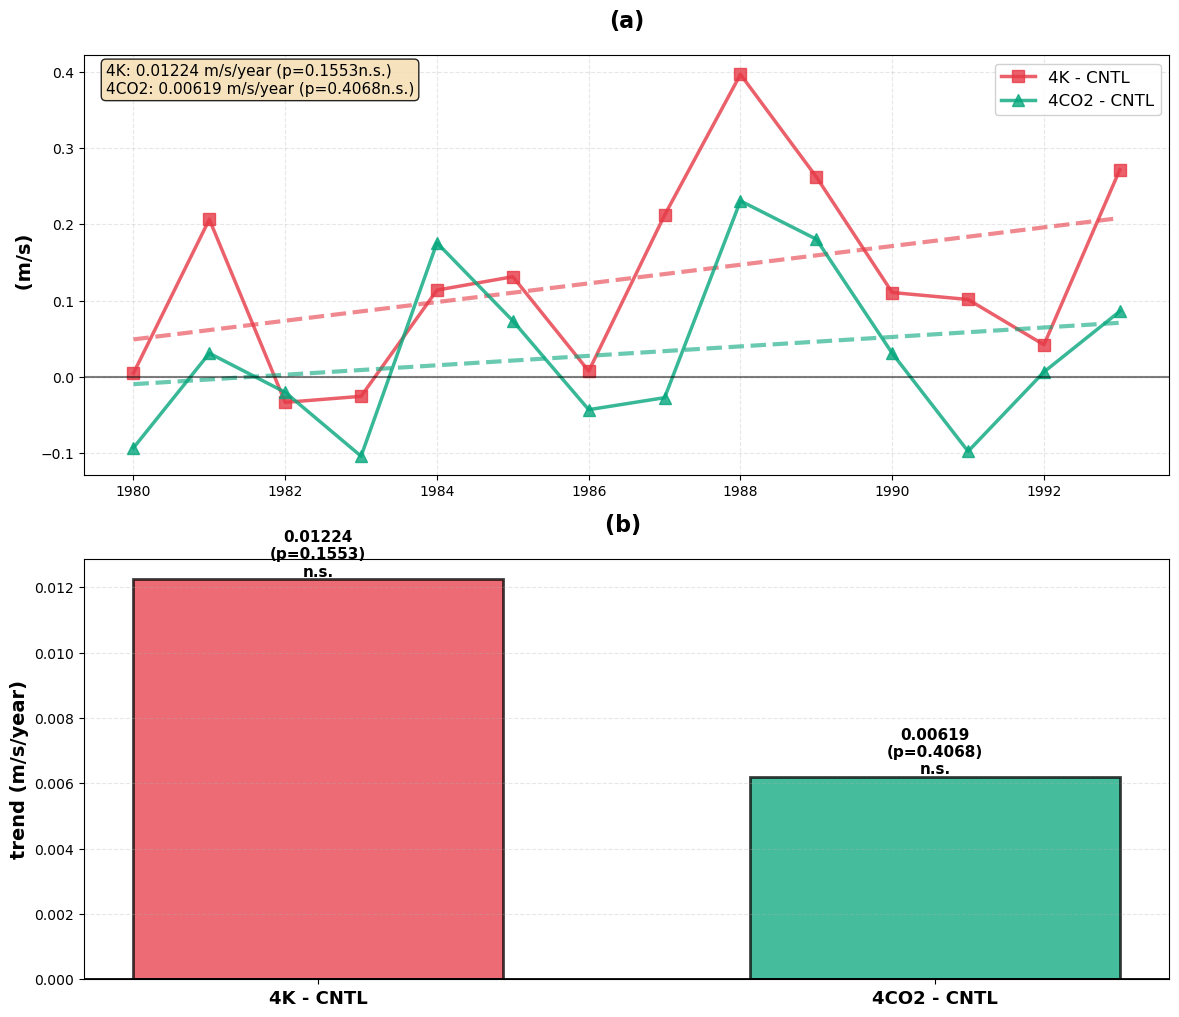

In [15]:
# 可视化速度异常值及其趋势
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

colors = {'4K': '#E63946', '4CO2': '#06A77D'}
markers = {'4K': 's', '4CO2': '^'}

# === 子图1: 异常值时间序列 ===
ax1 = axes[0]

for exp_name, data in speed_anomalies.items():
    years = data['years']
    anomaly = data['anomaly']
    trend = anomaly_trends[exp_name]
    
    # 绘制原始数据
    ax1.plot(years, anomaly, 
            marker=markers[exp_name], 
            linestyle='-', 
            linewidth=2.5, 
            markersize=9,
            color=colors[exp_name],
            label=f"{exp_name} - CNTL",
            alpha=0.8)
    
    # 绘制趋势线
    trend_line = trend['slope'] * years + trend['intercept']
    ax1.plot(years, trend_line, 
            linestyle='--', 
            linewidth=3,
            color=colors[exp_name],
            alpha=0.6)

# 添加零线
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)

ax1.set_xlabel('', fontsize=14, fontweight='bold')
ax1.set_ylabel(' (m/s)', fontsize=14, fontweight='bold')
ax1.set_title('(a)', fontsize=16, fontweight='bold', pad=20)
ax1.legend(fontsize=12, loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')

# 添加统计信息
info_text = ""
for exp_name, trend in anomaly_trends.items():
    info_text += f"{exp_name}: {trend['slope']:.5f} m/s/year (p={trend['p_value']:.4f}{trend['significance']})\n"
ax1.text(0.02, 0.98, info_text.strip(), transform=ax1.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85))

# === 子图2: 趋势对比柱状图 ===
ax2 = axes[1]

exp_names = list(anomaly_trends.keys())
slopes = [anomaly_trends[name]['slope'] for name in exp_names]
colors_bar = [colors[name] for name in exp_names]

x_pos = np.arange(len(exp_names))
bars = ax2.bar(x_pos, slopes, color=colors_bar, alpha=0.75, edgecolor='black', linewidth=2, width=0.6)

# 添加零线
ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)

ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{name} - CNTL" for name in exp_names], fontsize=13, fontweight='bold')
ax2.set_ylabel('trend (m/s/year)', fontsize=14, fontweight='bold')
ax2.set_title('(b) ', fontsize=16, fontweight='bold', pad=20)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# 添加数值和显著性标注
for i, (bar, name) in enumerate(zip(bars, exp_names)):
    trend = anomaly_trends[name]
    height = bar.get_height()
    
    # 标注数值
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.5f}\n(p={trend["p_value"]:.4f})\n{trend["significance"]}',
             ha='center', va='bottom' if height > 0 else 'top',
             fontsize=11, fontweight='bold')


# 保存图像
save_path = f'{fig_save_path}/kelvin_speed_anomalies_vs_cntl.png'
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ 异常值图像已保存: {save_path}")

plt.show()